# IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import RandomOverSampler
from google.colab import files

# Set gaya visualisasi biar rapi
sns.set_theme(style="whitegrid")

# LOAD DATASET


In [ ]:
print("🔄 Memuat dataset...")
df = pd.read_csv('DATASETACC.csv', sep=';')

🔄 Memuat dataset...


# PREPROCESSING DATA

In [ ]:
# Menampilkan 5 data pertama
print("\n5 data pertama:")
display(df.head())


5 data pertama:


,subject_id,date,time,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2,activity,score
0,subject_1,05/05/2026,15:04:24.039,-5.20,-1.21,8.32,-0.15,-0.03,-0.17,-7.37,3.56,5.35,0.30,-0.20,0.03,hand_to_mouth,0
1,subject_1,05/05/2026,15:04:24.277,-4.00,-2.47,8.05,-0.19,0.22,0.01,-7.36,2.94,5.56,-0.40,0.04,0.07,hand_to_mouth,0
2,subject_1,05/05/2026,15:04:24.440,-4.83,-1.41,8.65,0.12,-0.14,-0.08,-7.57,2.87,5.79,-0.06,0.00,-0.02,hand_to_mouth,0
3,subject_1,05/05/2026,15:04:24.688,-4.63,-1.10,8.73,0.04,0.05,0.03,-7.64,2.91,6.16,0.06,-0.01,-0.01,hand_to_mouth,0
4,subject_1,05/05/2026,15:04:24.953,-4.54,-1.29,8.72,0.08,-0.04,0.04,-7.56,3.02,6.00,-0.00,0.01,-0.01,hand_to_mouth,0


In [ ]:
# Menampilkan informasi struktur dataset
print("\nInformasi dataset:")
df.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13968 entries, 0 to 13967
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subject_id  13968 non-null  object 
 1   date        13968 non-null  object 
 2   time        13968 non-null  object 
 3   ax1         13968 non-null  float64
 4   ay1         13968 non-null  float64
 5   az1         13968 non-null  float64
 6   gx1         13968 non-null  float64
 7   gy1         13968 non-null  float64
 8   gz1         13968 non-null  float64
 9   ax2         13968 non-null  float64
 10  ay2         13968 non-null  float64
 11  az2         13968 non-null  float64
 12  gx2         13968 non-null  float64
 13  gy2         13968 non-null  float64
 14  gz2         13968 non-null  float64
 15  activity    13968 non-null  object 
 16  score       13968 non-null  int64  
dtypes: float64(12), int64(1), object(4)
memory usage: 1.8+ MB


In [ ]:
# Menampilkan jumlah baris dan kolom
print("\nUkuran datasetg:")
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])


Ukuran datasetg:
Jumlah baris: 13968
Jumlah kolom: 17


In [ ]:
# Menampilkan jumlah nilai kosong sebelum preprocessing
print("\nJumlah nilai kosong:")
print(df.isnull().sum())


Jumlah nilai kosong:
subject_id    0
date          0
time          0
ax1           0
ay1           0
az1           0
gx1           0
gy1           0
gz1           0
ax2           0
ay2           0
az2           0
gx2           0
gy2           0
gz2           0
activity      0
score         0
dtype: int64


In [ ]:
# Menampilkan nama kolom sebelum dibersihkan
print("\nNama kolom sebelum dibersihkan:")
print(df.columns.tolist())


Nama kolom sebelum dibersihkan:
['subject_id', 'date', 'time', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'activity', 'score']


In [ ]:
# Membersihkan nama kolom dari spasi berlebih
df.columns = df.columns.str.strip()

# Mengisi nilai kosong pada kolom score dengan 0 dan mengubah ke integer
df['score'] = df['score'].fillna(0).astype(int)

# Mengisi nilai kosong pada kolom activity dengan label 'none'
df['activity'] = df['activity'].fillna('none')

#  EXPLORATORY DATA ANALYSIS (EDA)


📊 [EDA] Menampilkan Analisis Data Awal...


/tmp/ipykernel_2919/2990238506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='activity', order=df['activity'].value_counts().index, palette='viridis')


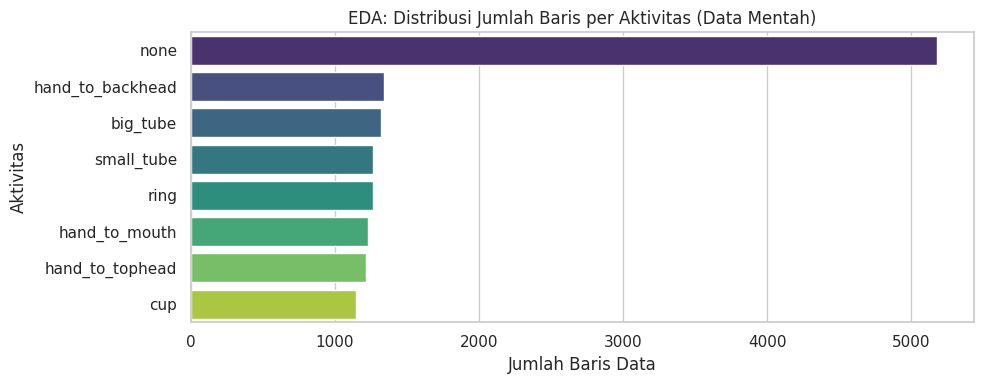

In [ ]:
print("\n📊 [EDA] Menampilkan Analisis Data Awal...")

# A. Distribusi Aktivitas Berdasarkan Sampel Baris Asli
plt.figure(figsize=(10, 4))
sns.countplot(data=df, y='activity', order=df['activity'].value_counts().index, palette='viridis')
plt.title('EDA: Distribusi Jumlah Baris per Aktivitas (Data Mentah)')
plt.xlabel('Jumlah Baris Data')
plt.ylabel('Aktivitas')
plt.tight_layout()
plt.show()

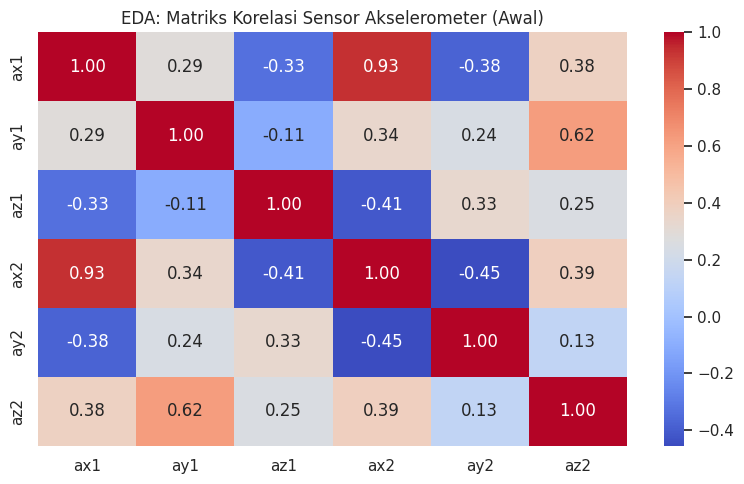

In [ ]:
# B. Korelasi Antar Sensor Utama
sensor_utama = ['ax1', 'ay1', 'az1', 'ax2', 'ay2', 'az2']
plt.figure(figsize=(8, 5))
sns.heatmap(df[sensor_utama].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('EDA: Matriks Korelasi Sensor Akselerometer (Awal)')
plt.tight_layout()
plt.show()

# FUNGSI EKSTRAKSI FITUR (WINDOWING)

In [ ]:
def extract_features(data, window_size=20, step_size=5):
    print(f"\n⚙️ Melakukan Ekstraksi Fitur (Window size: {window_size})...")
    feat_list = []
    sensor_cols = ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1',
                   'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2']

    for i in range(0, len(data) - window_size, step_size):
        win = data.iloc[i:i+window_size]
        row = []
        for c in sensor_cols:
            row.append(win[c].mean())
            row.append(win[c].std())
            row.append(win[c].max() - win[c].min())

        activity_mode = win['activity'].mode()
        row.append(activity_mode[0] if not activity_mode.empty else 'none')

        score_mode = win['score'].mode()
        row.append(score_mode[0] if not score_mode.empty else 0)

        feat_list.append(row)

    cols = []
    for c in sensor_cols: cols.extend([f'{c}_mean', f'{c}_std', f'{c}_range'])
    cols.extend(['activity', 'score'])
    return pd.DataFrame(feat_list, columns=cols)

df_features = extract_features(df)


⚙️ Melakukan Ekstraksi Fitur (Window size: 20)...


# TRAINING DATA

**TRAINING DENGAN STRATEGI COMBINED BALANCING**

In [ ]:
daftar_gerakan = ['hand_to_mouth', 'hand_to_backhead', 'hand_to_tophead',
                  'small_tube', 'big_tube', 'cup', 'ring']



 Menyeimbangkan & Memproses Model: HAND_TO_MOUTH


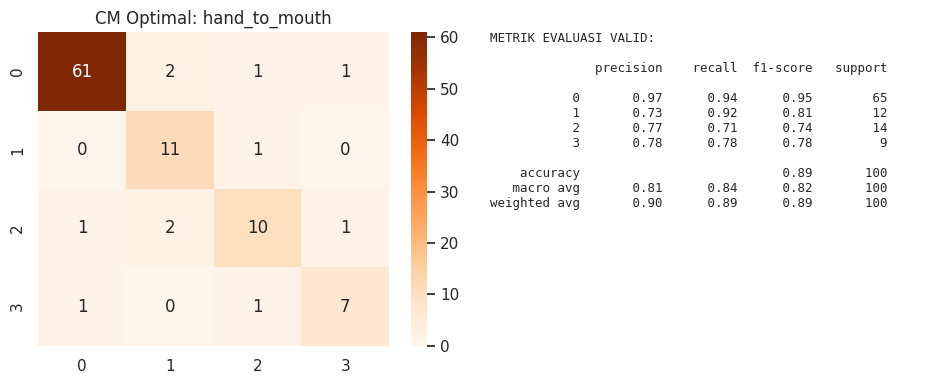


 Menyeimbangkan & Memproses Model: HAND_TO_BACKHEAD


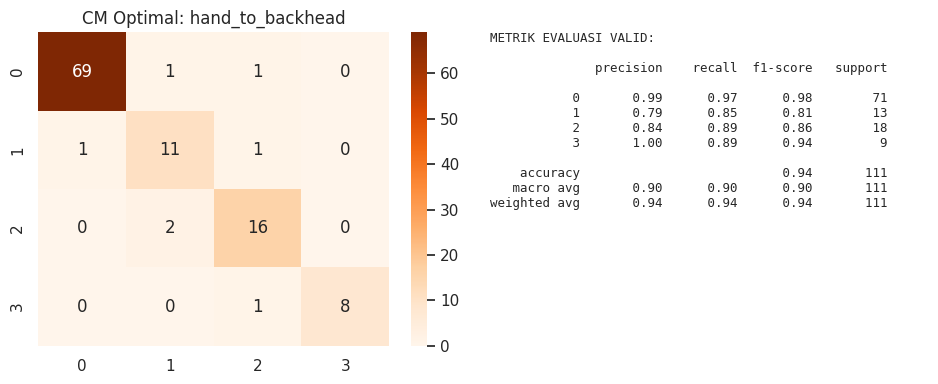


 Menyeimbangkan & Memproses Model: HAND_TO_TOPHEAD


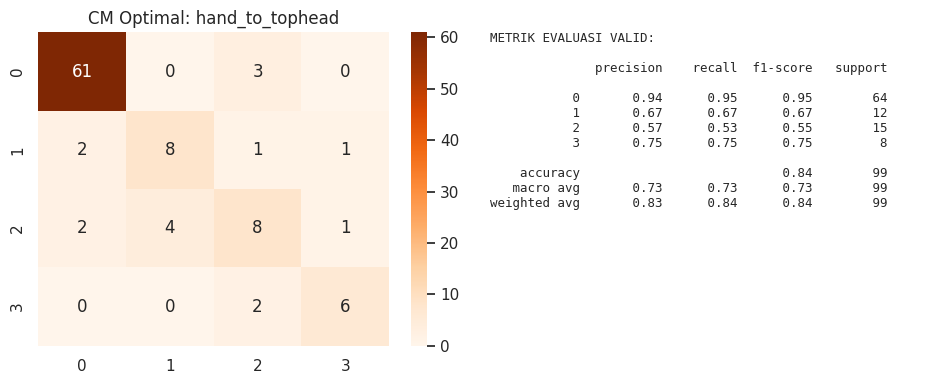


 Menyeimbangkan & Memproses Model: SMALL_TUBE


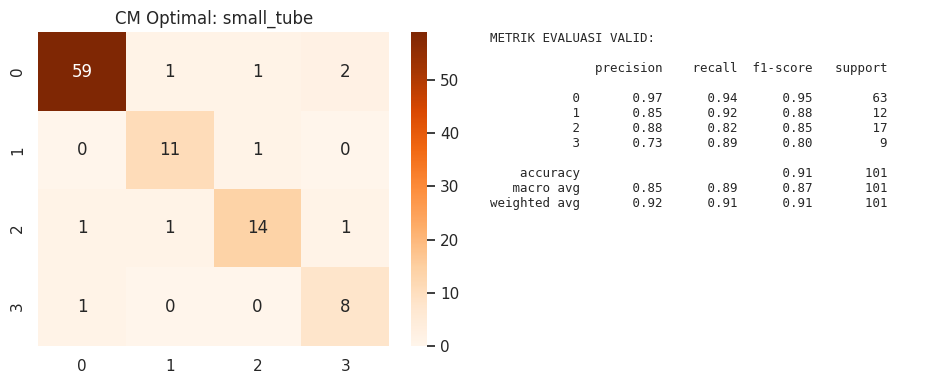


 Menyeimbangkan & Memproses Model: BIG_TUBE


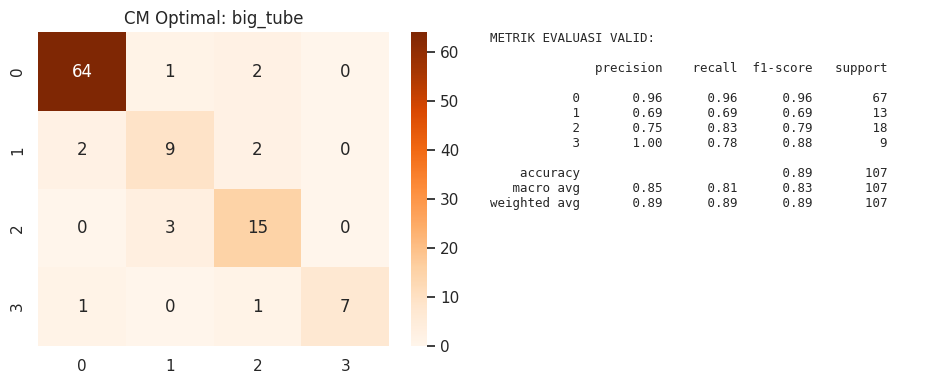


 Menyeimbangkan & Memproses Model: CUP


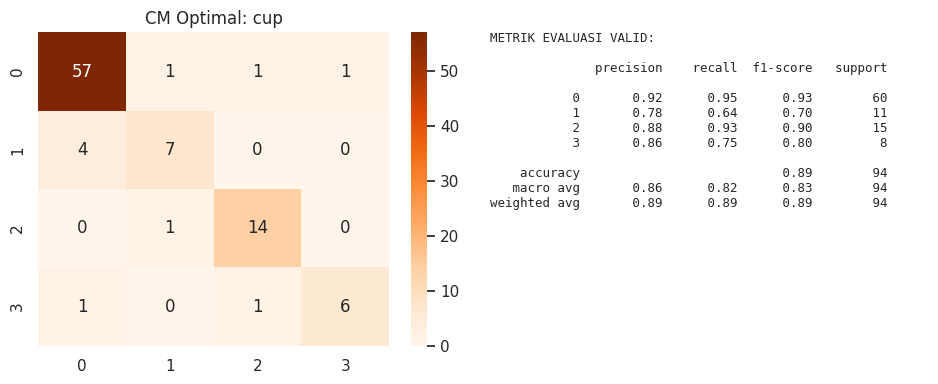


 Menyeimbangkan & Memproses Model: RING


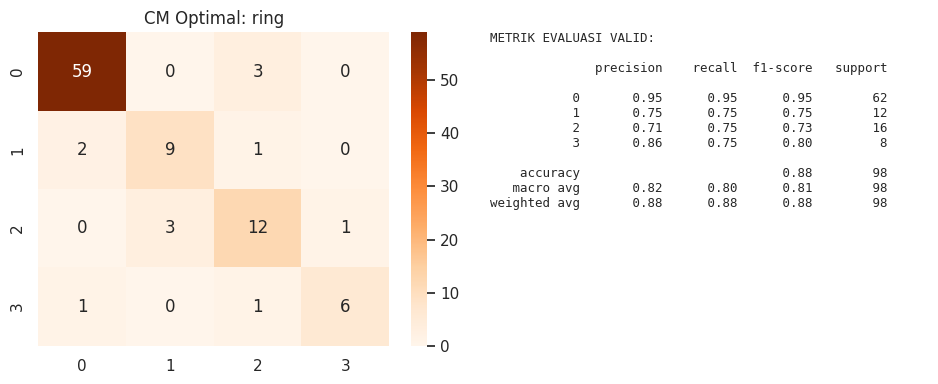

In [ ]:
# List penampung untuk rangkuman performa
rangkuman_data = []

for gerakan in daftar_gerakan:
    df_g = df_features[df_features['activity'] == gerakan]
    df_n = df_features[df_features['activity'] == 'none']

    if len(df_g) == 0:
        print(f"⚠️ Gerakan {gerakan} tidak ditemukan di dataset fitur.")
        continue

    print(f"\n Menyeimbangkan & Memproses Model: {gerakan.upper()}")

    # --- TAHAP 1: AUTOMATIC UNDER-SAMPLING UNTUK DATA 'NONE' ---
    jumlah_maksimal_none = len(df_g)
    df_n_pangkas = df_n.sample(n=min(len(df_n), jumlah_maksimal_none), random_state=42)

    data_gabung = pd.concat([df_g, df_n_pangkas])

    X = data_gabung.drop(['activity', 'score'], axis=1)
    y = data_gabung['score']

    # --- TAHAP 2: SPLIT SEBELUM OVER-SAMPLING (Anti Bocor) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) > 1 else None
    )

    # --- TAHAP 3: OVER-SAMPLING HANYA PADA SKOR DI DATA TRAINING ---
    ros = RandomOverSampler(random_state=42)
    X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

    # Training Model
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_resampled, y_train_resampled)

    # Uji coba pada data test
    y_pred = rf.predict(X_test)

    # --- HITUNG METRIK UNTUK TABEL RANGKUMAN (Macro Average) ---
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Simpan hasil metrik ke list rangkuman
    rangkuman_data.append({
        'Model Gerakan': gerakan,
        'Jumlah Sampel': len(df_g),
        'Accuracy': round(acc, 2),
        'Precision (Macro)': round(prec, 2),
        'Recall (Macro)': round(rec, 2),
        'F1-Score (Macro)': round(f1, 2)
    })

    # --- VISUALISASI HASIL AKHIR PER MODEL ---
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    all_labels = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=all_labels, yticklabels=all_labels)
    plt.title(f'CM Optimal: {gerakan}')

    plt.subplot(1, 2, 2)
    plt.axis('off')
    report = classification_report(y_test, y_pred, labels=all_labels, zero_division=0)
    plt.text(0, 1, f"METRIK EVALUASI VALID:\n\n{report}", fontsize=9, family='monospace', verticalalignment='top')
    plt.tight_layout()
    plt.show()

    # Simpan pkl
    joblib.dump(rf, f'model_{gerakan}.pkl')


# RANGKUMAN HASIL AKHIR 7 MODEL

In [ ]:
print("\n📋 [HASIL AKHIR] Rangkuman Evaluasi Ke-7 Model:")
df_rangkuman = pd.DataFrame(rangkuman_data)

# Tampilkan dalam bentuk tabel Pandas
display(df_rangkuman)




📋 [HASIL AKHIR] Rangkuman Evaluasi Ke-7 Model:


,Model Gerakan,Jumlah Sampel,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,hand_to_mouth,250,0.89,0.81,0.84,0.82
1,hand_to_backhead,276,0.94,0.90,0.90,0.90
2,hand_to_tophead,247,0.84,0.73,0.73,0.73
3,small_tube,251,0.91,0.85,0.89,0.87
4,big_tube,266,0.89,0.85,0.81,0.83
5,cup,235,0.89,0.86,0.82,0.83
6,ring,245,0.88,0.82,0.80,0.81


/tmp/ipykernel_2919/3548916855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rangkuman, x='F1-Score (Macro)', y='Model Gerakan', palette='Blues_r')


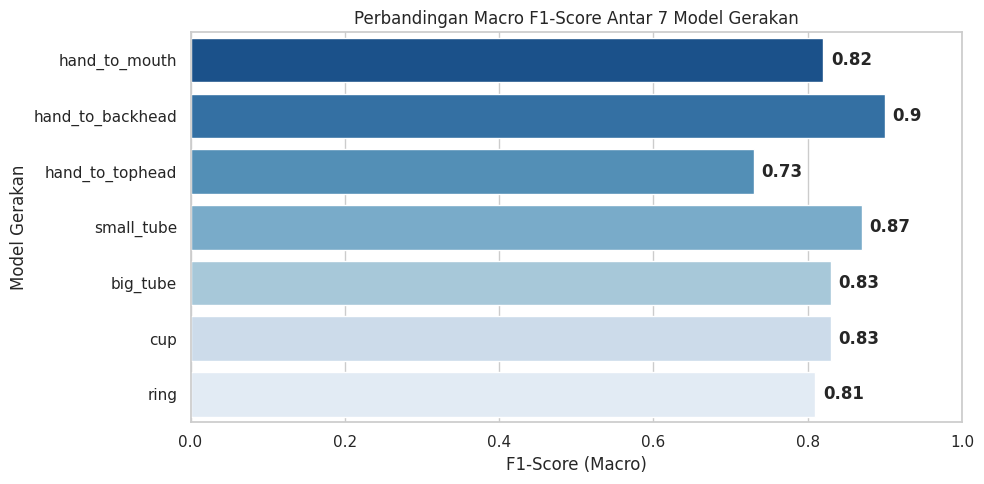

In [ ]:
# Visualisasi Perbandingan F1-Score Makro Antar Model
plt.figure(figsize=(10, 5))
sns.barplot(data=df_rangkuman, x='F1-Score (Macro)', y='Model Gerakan', palette='Blues_r')
plt.xlim(0, 1.0)
for index, value in enumerate(df_rangkuman['F1-Score (Macro)']):
    plt.text(value + 0.01, index, f'{value}', va='center', fontweight='bold')
plt.title('Perbandingan Macro F1-Score Antar 7 Model Gerakan')
plt.tight_layout()
plt.show()